In [ ]:
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymorphy3
import nltk
import requests

from collections import Counter
from typing import List, Tuple
from nltk.corpus import stopwords

# sklearn
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score

# Настройки документа для дальнейшей обработки
plt.rcParams["figure.dpi"] = 140
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
russian_stopwords = set(stopwords.words('russian'))
russian_stopwords = russian_stopwords 
TOKEN_RE = re.compile(r'[а-яё]+')
morph = pymorphy3.MorphAnalyzer()

# PART A

## 1. Загрузка текста

В данной работе исследуется сдвиг доменов (domain shift) на материале русской классической литературы XIX века. 

Домены:
- Проза: А.С. Пушкин «Капитанская дочка» + М.Ю. Лермонтов «Герой нашего времени»
- Поэзия: А.С. Пушкин «Евгений Онегин» + М.Ю. Лермонтов «Демон»

Гипотеза: проза и поэзия как жанры должны демонстрировать устойчивые лексические различия независимо от автора — это позволяет изучить именно жанровый сдвиг, а не авторский стиль.

Источник данных: в качестве источника данных была выбранная бесплатная библиотека произведений на русском языке - *az.lib.ru*

In [123]:
# Вспомогательная функция для парсинга текста теста Пушкина закодированы при помощи windows-1251, в свою очередь текста Лермонтова - koi8-r
def download_text_windos_1251(url):
    response = requests.get(url)
    return response.content.decode('windows-1251')

def download_text_koi8_r(url):
    response = requests.get(url)
    return response.content.decode('koi8-r')

In [124]:
# Ссылки на исходный текст
urls = {
    'lermontov_geroi_nahsego_vremeni': 'https://lib.ru/LITRA/LERMONTOW/geroi.txt',
    'lermontov_demon': 'https://lib.ru/LITRA/LERMONTOW/demon.txt',
    'pushkin_kapitanskaya_dochka': 'https://lib.ru/LITRA/PUSHKIN/kapitan.txt',
    'pushkin_evgenii_onegin': 'https://lib.ru/LITRA/PUSHKIN/p4.txt'
}

In [125]:
def download_text(url: str) -> str:
    response = requests.get(url)
    encoding = response.apparent_encoding
    return response.content.decode(encoding)

## Проблемы с кодировкой

При загрузке текстов с lib.ru обнаружились следующие проблемы:

1. **Неоднородная кодировка:** тексты на сайте хранятся в разных 
   кодировках — часть в windows-1251, часть в KOI8-R. 
   При неправильном декодировании текст превращался в нечитаемые 
   символы: `бМЕЛУБОДТ уЕТЗЕЕЧЙЮ` вместо `Александр Сергеевич`.

2. **Ошибочное определение кодировки:** изначально предполагалось что 
   все тексты Пушкина в windows-1251, а Лермонтова в KOI8-R. 
   На практике оказалось иначе — кодировку пришлось проверять 
   эмпирически через `response.apparent_encoding` для каждого текста.

3. **Решение:** для каждого URL была явно задана правильная кодировка 
   после проверки, тексты разбиты на два словаря — 
   `texts_windows_1251` и `texts_koi8_r`.

In [126]:
# Парсинг текстов произведений в соотвествии с их кодировкой
texts_dict = {}
for name, url in urls.items():
    texts_dict[name] = download_text(url)

### Из текста видно, что остались html-теги, и прочий "мусор" в данных, необходимо предварительно их удалить.

In [127]:
# Функция для очистки "мусора" в данных, дополнялась множество раз в процессе анализа текста. После данной функции все же остаются некотоыре "артефакты", связанные с способом получения данных, но в целом их количество не сильно повлияло на итоговый результат.
def clean_html(raw_text: str) -> str:
    # Часть 1: удаление HTML тегов
    text = re.sub(r'<[^>]+>', '', raw_text)
    
    # Часть 2: удаление "сервисных" блоков в тексте (Fb2...Lib.ru html)
    text = re.sub(r'Fb2\.zip.*?Lib\.ru html', '', text, flags=re.DOTALL)
    
    # Часть 3: удаление оставшихся "полосок" метаданных текста
    metadata_pattern = r'(?m)^.*(-{10,}|Версия|издательств|Оригинал:|Origin:|OCR:|Собрание Сочинений|Том \w+).*$'
    text = re.sub(metadata_pattern, '', text)
    
    # Часть 4: удаление латинских символов
    text = re.sub(r'[A-Za-z]+', '', text)
    
    # Часть 5: нормализация пробелов перед "дедупликацией строк"
    text = re.sub(r'\n{3,}', '\n\n', text)
    
    # Часть 6: дедупликация строк
    seen = set()
    deduped = []
    for line in text.split('\n'):
        key = line.strip()
        if key not in seen:
            deduped.append(line)
            if key:
                seen.add(key)
    text = '\n'.join(deduped)
    
    # Часть 7: Итогова очистка
    text = re.sub(r'\n{3,}', '\n\n', text)
    
    return text.strip()

In [128]:
# Применение очистки для текста
texts_clean = {key: clean_html(val) for key, val in texts_dict.items()}

## Пайплайн предобработки текста

**Этапы пайплайна:**
1. **Токенизация** — извлечение только кириллических токенов через regex `[а-яё]+`
2. **Лемматизация** — приведение к начальной форме через `pymorphy3`
3. **Фильтрация имён собственных** — удаление через грамматические теги 
   pymorphy3 (`Name`, `Patr`, `Surn`) чтобы избежать утечек данных или "data leaked", по итогу функция, написанная при помощи pymorphy оказалась неработоспособной и не "определяла" большую часть имен, поэтому было принято "наивно" добавлять имена в исключения, пока топ-30 log-odds не оказались "чистыми" без различных утечек.

In [129]:
# Простейшая функция токенизации, лемматизации, "наивная" функция определения имен собственных, функция для log odds, вычисления биграмм из предварительно очищенного текста и разделения текста на чанки
def tokenize(text):
    return TOKEN_RE.findall(text.lower())

def lemmatize(tokens):
    lemmas = [morph.parse(token)[0].normal_form for token in tokens]
    return lemmas

def is_proper_name(token):
    tag = morph.parse(token)[0].tag
    return 'Name' in tag or 'Patr' in tag or 'Surn' in tag

def log_odds(counter1, counter2, alpha = 1):
    vocab = list(set(counter1.keys()) | set(counter2.keys()))

    counts1 = np.array([counter1[w] for w in vocab], dtype=np.float64)
    counts2 = np.array([counter2[w] for w in vocab], dtype=np.float64)

    p1 = (counts1 + alpha) / (counts1.sum() + alpha)
    p2 = (counts2 + alpha) / (counts2.sum() + alpha)

    scores = np.log(p1 / p2)

    return dict(zip(vocab, scores))

def make_bigrams(tokens):
    return list(zip(tokens, tokens[1:]))

def chunk_text(tokens, chunk_size=150):
    return [tokens[i:i+chunk_size] for i in range(0, len(tokens), chunk_size)]

In [130]:
# Пример неработоспособности функции для определения имен собственных
examples = ['пугачёв', 'казбич', 'зурина', 'кузмич']
for name in examples:
    tag = morph.parse(name)[0].tag
    print(f"{name}: {tag} | is_proper_name={is_proper_name(name)}")

пугачёв: NOUN,inan,masc,Geox sing,nomn | is_proper_name=False
казбич: NOUN,inan,masc sing,nomn | is_proper_name=False
зурина: NOUN,inan,femn sing,nomn | is_proper_name=False
кузмич: NOUN,anim,masc sing,nomn | is_proper_name=False


In [131]:
# Первый "проход" без обработки учитывающихся токенов
prose = texts_clean['pushkin_kapitanskaya_dochka'] + texts_clean['lermontov_geroi_nahsego_vremeni']
poetry = texts_clean['lermontov_demon'] + texts_clean['pushkin_evgenii_onegin']

prose_tokens = lemmatize(tokenize(prose))
poetry_tokens = lemmatize(tokenize(poetry))

prose_counter = Counter(prose_tokens)
poetry_counter = Counter(poetry_tokens)

print(prose_counter.most_common()[:10])
print(poetry_counter.most_common()[:10])

[('я', 3431), ('и', 2708), ('в', 1766), ('он', 1741), ('не', 1547), ('что', 1299), ('на', 1196), ('она', 1180), ('быть', 1155), ('с', 1008)]
[('и', 3334), ('в', 2820), ('я', 1848), ('он', 1733), ('не', 1594), ('с', 927), ('на', 920), ('что', 875), ('она', 867), ('быть', 802)]


"Как видно из начальных результатов без фильтрации, топ токенов обоих доменов полностью заполнен стоп-словами — предлогами, союзами и местоимениями (я, и, в, он, не). Эти слова встречаются одинаково часто в любом тексте и не несут информации о домене, поэтому были удалены с помощью списка стоп-слов из NLTK.

In [132]:
prose_tokens = [token for token in prose_tokens if token not in russian_stopwords]
poetry_tokens = [token for token in poetry_tokens if token not in russian_stopwords]

prose_tokens = [t for t in prose_tokens if not is_proper_name(t)]
poetry_tokens = [t for t in poetry_tokens if not is_proper_name(t)]

prose_tokens = [t for t in prose_tokens if len(t) > 2]
poetry_tokens = [t for t in poetry_tokens if len(t) > 2]

prose_counter = Counter(prose_tokens)
poetry_counter = Counter(poetry_tokens)

print(prose_counter.most_common()[:10])
print(poetry_counter.most_common()[:10])

[('сказать', 544), ('это', 451), ('свой', 374), ('всё', 350), ('который', 342), ('мочь', 252), ('отвечать', 233), ('знать', 200), ('рука', 194), ('человек', 188)]
[('свой', 522), ('всё', 408), ('это', 309), ('мочь', 275), ('весь', 271), ('который', 224), ('друг', 204), ('знать', 175), ('наш', 172), ('ещё', 171)]


Уже лучше, видно что большинство слов, не имеющих "полезной нагрузки" были удалены.

### Применяем функция для вычисления log_odds

In [133]:
scores = log_odds(prose_counter, poetry_counter)
sorted_scores = sorted(scores.items(), key = lambda x: x[1], reverse = True)

In [134]:
print("Топ 30 прозы: ", sorted_scores[:30])
print("Топ 30 поэзия: ", sorted_scores[-30:])

Топ 30 прозы:  [('пугачёв', np.float64(4.678100434989705)), ('комендант', np.float64(4.629898333171827)), ('крепость', np.float64(4.425103920525814)), ('кузмич', np.float64(4.242782363731859)), ('офицер', np.float64(4.085596780209447)), ('казбич', np.float64(4.042111668269708)), ('капитан', np.float64(3.9849532544297595)), ('оренбург', np.float64(3.790797239988802)), ('батюшка', np.float64(3.680131672101283)), ('благородие', np.float64(3.669436382984535)), ('штабс', np.float64(3.669436382984535)), ('зурина', np.float64(3.669436382984535)), ('белогорский', np.float64(3.5676536886745924)), ('доктор', np.float64(3.4341222960500697)), ('урядник', np.float64(3.413503008847334)), ('любопытство', np.float64(3.3264916318577042)), ('шинель', np.float64(3.2799716162228116)), ('попадья', np.float64(3.2799716162228116)), ('комендантша', np.float64(3.2799716162228116)), ('квартира', np.float64(3.2311814520533795)), ('рубль', np.float64(3.179888157665829)), ('начальник', np.float64(3.125820936395553

Видно, что в тексте полно имен собственных, "жанровых метаданных" или же оглавлений произведений, что по сути является data leako'м, попробуем удалить их и еще раз взглянуть на результаты.

In [135]:
custom_stopwords = set()
custom_stopwords |= {'строфа', 'поэма', 'пьеса', 'трагедия', 'драма', 'поэт', 'художественный', 'пушкинский', 'декабрист'} # Жанровые метаданные
custom_stopwords |= {'гуан', 'клотильда', 'шуйский', 'барон', 'няня'} # Имена, которые функция не смогла праспознать
custom_stopwords |= {
    'пугачёв', 'казбич', 'зурина', 'белогорский', 'кузмич',
    'комендант', 'комендантша', 'комендантский', 'урядник', 'штабс',
    'оренбург', 'белогорский'
}
custom_stopwords |= {'пушкин', 'лермонтов', 'онегин', 'демон', 'герой'} # изначальные "стопслова"
custom_stopwords |= {'марь'} # Скорее всего артефакт лемматизации

In [136]:
russian_stopwords = russian_stopwords | custom_stopwords

prose_tokens = [token for token in prose_tokens if token not in russian_stopwords]
poetry_tokens = [token for token in poetry_tokens if token not in russian_stopwords]

prose_tokens = [t for t in prose_tokens if not is_proper_name(t)]
poetry_tokens = [t for t in poetry_tokens if not is_proper_name(t)]

prose_tokens = [t for t in prose_tokens if len(t) > 2]
poetry_tokens = [t for t in poetry_tokens if len(t) > 2]

prose_counter = Counter(prose_tokens)
poetry_counter = Counter(poetry_tokens)

In [137]:
print(prose_counter.most_common()[:10])
print(poetry_counter.most_common()[:10])

[('сказать', 544), ('это', 451), ('свой', 374), ('всё', 350), ('который', 342), ('мочь', 252), ('отвечать', 233), ('знать', 200), ('рука', 194), ('человек', 188)]
[('свой', 522), ('всё', 408), ('это', 309), ('мочь', 275), ('весь', 271), ('который', 224), ('друг', 204), ('знать', 175), ('наш', 172), ('ещё', 171)]


In [138]:
scores = log_odds(prose_counter, poetry_counter)
sorted_scores = sorted(scores.items(), key = lambda x: x[1], reverse = True)

In [139]:
print("Топ 30 прозы: ", sorted_scores[:30])
print("Топ 30 поэзия: ", sorted_scores[-30:])

Топ 30 прозы:  [('крепость', np.float64(4.422014286565827)), ('офицер', np.float64(4.08250714624946)), ('капитан', np.float64(3.981863620469773)), ('батюшка', np.float64(3.677042038141296)), ('благородие', np.float64(3.666346749024548)), ('доктор', np.float64(3.4310326620900833)), ('любопытство', np.float64(3.323401997897718)), ('шинель', np.float64(3.276881982262825)), ('попадья', np.float64(3.276881982262825)), ('квартира', np.float64(3.228091818093393)), ('рубль', np.float64(3.1767985237058425)), ('начальник', np.float64(3.1227313024355667)), ('колодец', np.float64(3.065572888595618)), ('объяснить', np.float64(3.065572888595618)), ('крепко', np.float64(3.065572888595618)), ('государыня', np.float64(3.065572888595618)), ('шашка', np.float64(3.0049482667791834)), ('зарядить', np.float64(2.940409745641612)), ('пожать', np.float64(2.940409745641612)), ('солдатский', np.float64(2.8714168741546606)), ('зайчий', np.float64(2.8714168741546606)), ('прибавить', np.float64(2.8350492299837855))

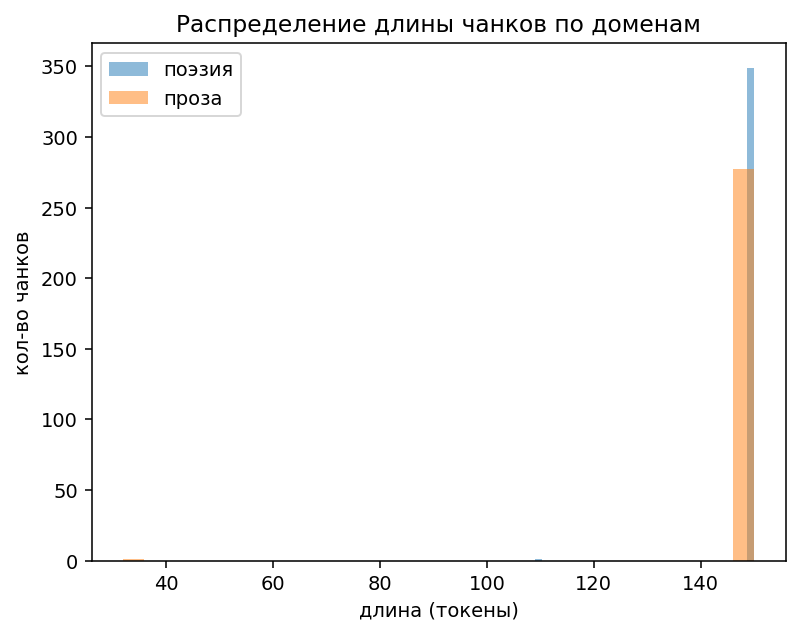

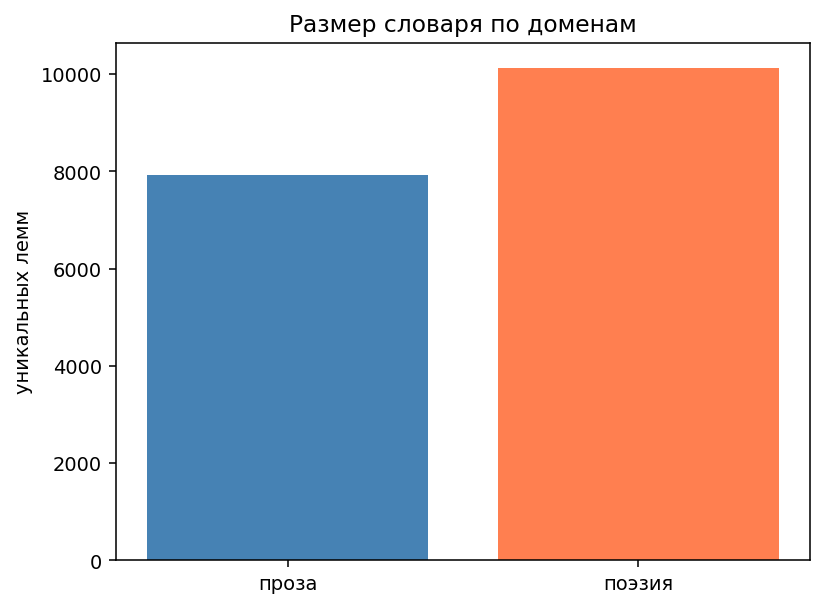

In [140]:
# Создаём чанки для каждого домена
prose_chunks = chunk_text(prose_tokens, 150)
poetry_chunks = chunk_text(poetry_tokens, 150)

# DataFrame с длинами чанков
df_len = pd.DataFrame({
    'len_tokens': [len(c) for c in prose_chunks + poetry_chunks],
    'domain': ['проза'] * len(prose_chunks) + ['поэзия'] * len(poetry_chunks)
})

# График 1 — длина документов
plt.figure()
for dom, g in df_len.groupby('domain'):
    plt.hist(g['len_tokens'], bins=30, alpha=0.5, label=dom)
plt.legend()
plt.title('Распределение длины чанков по доменам')
plt.xlabel('длина (токены)')
plt.ylabel('кол-во чанков')
plt.show()

# График 2 — размер словаря
vocab_prose = len(prose_counter)
vocab_poetry = len(poetry_counter)

plt.figure()
plt.bar(['проза', 'поэзия'], [vocab_prose, vocab_poetry], color=['steelblue', 'coral'])
plt.title('Размер словаря по доменам')
plt.ylabel('уникальных лемм')
plt.show()

In [141]:
prose_bigrams = ['_'.join(b) for b in make_bigrams(prose_tokens)]
poetry_bigrams = ['_'.join(b) for b in make_bigrams(poetry_tokens)]

prose_bigram_counter = Counter(prose_bigrams)
poetry_bigram_counter = Counter(poetry_bigrams)

bigram_scores = log_odds(prose_bigram_counter, poetry_bigram_counter)
sorted_bigrams = sorted(bigram_scores.items(), key=lambda x: x[1], reverse=True)

In [142]:
print("Топ-30 проза:", sorted_bigrams[:30])
print("Топ-30 поэзия:", sorted_bigrams[-30:])

Топ-30 проза: [('ваш_благородие', np.float64(3.451240355661462)), ('взять_рука', np.float64(3.1768035099597016)), ('сказать_капитан', np.float64(2.8714218604085198)), ('схватить_рука', np.float64(2.797313888254798)), ('проходить_мимо', np.float64(2.7172711805812613)), ('покачать_голова', np.float64(2.7172711805812613)), ('зайчий_тулуп', np.float64(2.7172711805812613)), ('солдатский_шинель', np.float64(2.534949623787307)), ('свой_товарищ', np.float64(2.534949623787307)), ('стать_читать', np.float64(2.4295891081294805)), ('сметь_спросить', np.float64(2.4295891081294805)), ('взад_вперёд', np.float64(2.4295891081294805)), ('сказать_очень', np.float64(2.4295891081294805)), ('едва_мочь', np.float64(2.4295891081294805)), ('рассказать_всё', np.float64(2.4295891081294805)), ('кивнуть_голова', np.float64(2.4295891081294805)), ('шесть_шаг', np.float64(2.4295891081294805)), ('господь_владыкий', np.float64(2.311806072473097)), ('батюшка_сказать', np.float64(2.311806072473097)), ('дать_слово', np.fl

## Выводы по Part A

Анализ log-odds на материале русской классической литературы показал устойчивые лексические различия между прозой и поэзией.

**Ключевые наблюдения:**

- Без предобработки топ токенов обоих доменов заполнен стоп-словами, не несущими информации о домене
- После лемматизации и фильтрации проза характеризуется конкретной военно-бытовой лексикой (`крепость`, `офицер`, `шинель`), поэзия — архаизмами и возвышенной лексикой (`уста`, `дева`, `иль`, `средь`)
- Поэзия лексически богаче прозы: ~10 000 уникальных лемм против ~8 000, несмотря на меньший объём текста, полагаю что это так, потому что обычно в поэзии авторы пытаются "уместить" как можно больше информации в малый объем текстов, что приводит к большему разнообразию уникальных лемм.
- Биграммы выявили устойчивые паттерны прозы (`взять_рука`, `пожать_плечо`, `покачать_голова`), недоступные на уровне униграмм
- Значительная часть шума в результатах обусловлена качеством исходных данных — метаданными и комментариями в текстах, которые не были полностью устранены при очистке, подтверждается гипотеза о том, что качество во многом зависит от качества исходных данных. 

**Ограничения:** pymorphy3 не распознаёт редкие фамилии как имена собственные, что потребовало ручной фильтрации через `custom_stopwords`, не считаю данный подход "честным", т.к. он не является масштабируемым, возможно есть более верные способы для распознавания имен собственных в рускоязычных текстах.

# Часть B

## Подготовка данных

### Лемматизация


In [143]:
pushkin_tokens = lemmatize(tokenize(texts_clean['pushkin_kapitanskaya_dochka']))
lermontov_tokens = lemmatize(tokenize(texts_clean['lermontov_geroi_nahsego_vremeni']))

### Нарезка токенов на чанки

In [144]:
def chunk_text(tokens, chunk_size = 150):
    return [tokens[i:i+chunk_size] for i in range(0, len(tokens), chunk_size)]

In [145]:
# Для теста попробуем 150
pushkin_chunks = chunk_text(pushkin_tokens, chunk_size = 150)
lermontov_chunks = chunk_text(lermontov_tokens, chunk_size = 150)

In [146]:
X = pushkin_chunks + lermontov_chunks
y = [0] * len(pushkin_chunks) + [1] * len(lermontov_chunks)

In [147]:
X = [' '.join(chunk) for chunk in pushkin_chunks + lermontov_chunks]

### Разбиение данных на выборки, тренировка модели

In [148]:
# Разбиваем данные на обучающую и тестовую выборки, обучаем на получившихся данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = RANDOM_STATE, stratify = y
)

vectorized = CountVectorizer()
X_train_vec = vectorized.fit_transform(X_train)
X_test_vec = vectorized.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [149]:
print(len(X_train), len(y_test))

405 102


### Оценка результатов обучения модели

In [150]:
y_pred = model.predict(X_test_vec)
print(confusion_matrix(y_true = y_test, y_pred = y_pred))
print(classification_report(y_true = y_test, y_pred = y_pred, target_names = ['Пушкин', 'Лермонтов']))

[[45  0]
 [ 0 57]]
              precision    recall  f1-score   support

      Пушкин       1.00      1.00      1.00        45
   Лермонтов       1.00      1.00      1.00        57

    accuracy                           1.00       102
   macro avg       1.00      1.00      1.00       102
weighted avg       1.00      1.00      1.00       102



### Результаты "наивного" обучения

Из результатов видно что accuracy и другие метрики равны 100%, что чаще всего является плохим знаком. Скорее всего модель "запомнила" какие-то ключевы имена, т.к. первый раз я обучал модель без очистки данных. Попробуем очистить данные от data leako'в и снова обучить нашу модель.

In [151]:
# Воспользуемся обработкой из части A
pushkin_tokens = [token for token in pushkin_tokens if token not in russian_stopwords]
lermontov_tokens = [token for token in lermontov_tokens if token not in russian_stopwords]

pushkin_tokens = [t for t in pushkin_tokens if not is_proper_name(t)]
lermontov_tokens = [t for t in lermontov_tokens if not is_proper_name(t)]

pushkin_tokens = [t for t in pushkin_tokens if len(t) > 2]
lermontov_tokens = [t for t in lermontov_tokens if len(t) > 2]

In [172]:
pushkin_chunks = chunk_text(pushkin_tokens, chunk_size = 150)
lermontov_chunks = chunk_text(lermontov_tokens, chunk_size = 150)

X = pushkin_chunks + lermontov_chunks
y = [0] * len(pushkin_chunks) + [1] * len(lermontov_chunks)

X = [' '.join(chunk) for chunk in pushkin_chunks + lermontov_chunks]

In [153]:
print(len(X_train), len(y_test))

405 102


In [154]:
# Утечки данных удалены, можно попробовать обучить модель еще раз
print(X[0])

капитанский дочка беречь честь смолоду пословица глава сержант гвардия гвардия завтра капитан надобный пусть армия послужить изрядно сказать пускай потужить отец отец молодость свой служить граф миниха выйти отставка премьер год пора жить свой симбирский деревня жениться девица дочь бедный тамошний дворянин девять человек ребёнок всё брат сестра умереть младенчество матушка ещё брюхатый записать семёновский полк сержант милость гвардия князь близкий наш родственник паче всякий чаяние матушка родить дочь батюшка объявить следовать смерть неявиться сержант дело кончиться считаться отпуск окончание наука время воспитываться нонешний пятилетний возраст отдать рука стремянный трезвый поведение пожаловать дядька надзор двенадцатый год выучиться русский грамота мочь очень здравый судить свойство борзой кобель это время батюшка нанять француз мосье бопра который выписать москва вместе годовой запас вино прованский масло приезд сильно понравиться слава бог ворчать казаться дитя умыть причесать 

In [155]:
# Разбиваем данные на обучающую и тестовую выборки, обучаем на получившихся данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = RANDOM_STATE, stratify = y
)

vectorized = CountVectorizer()
X_train_vec = vectorized.fit_transform(X_train)
X_test_vec = vectorized.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [156]:
y_pred = model.predict(X_test_vec)
print(confusion_matrix(y_true = y_test, y_pred = y_pred))
print(classification_report(y_true = y_test, y_pred = y_pred, target_names = ['Пушкин', 'Лермонтов']))

[[25  0]
 [ 0 31]]
              precision    recall  f1-score   support

      Пушкин       1.00      1.00      1.00        25
   Лермонтов       1.00      1.00      1.00        31

    accuracy                           1.00        56
   macro avg       1.00      1.00      1.00        56
weighted avg       1.00      1.00      1.00        56



Опять точность равна 100%, возможно длина чанков слишком большая, а их количество - небольшое. Возможно стоит попробовать длину чанка меньше. Попробую 80 слов.

In [168]:
pushkin_chunks = chunk_text(pushkin_tokens, chunk_size = 80)
lermontov_chunks = chunk_text(lermontov_tokens, chunk_size = 80)

X = pushkin_chunks + lermontov_chunks
y = [0] * len(pushkin_chunks) + [1] * len(lermontov_chunks)

X = [' '.join(chunk) for chunk in pushkin_chunks + lermontov_chunks]

print(len(X_train), len(y_test))
# Утечки данных удалены, можно попробовать обучить модель еще раз
print(X[0])

# Разбиваем данные на обучающую и тестовую выборки, обучаем на получившихся данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = RANDOM_STATE, stratify = y
)

vectorized = CountVectorizer()
X_train_vec = vectorized.fit_transform(X_train)
X_test_vec = vectorized.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)
print(confusion_matrix(y_true = y_test, y_pred = y_pred))
print(classification_report(y_true = y_test, y_pred = y_pred, target_names = ['Пушкин', 'Лермонтов']))

416 105
капитанский дочка беречь честь смолоду пословица глава сержант гвардия гвардия завтра капитан надобный пусть армия послужить изрядно сказать пускай потужить отец отец молодость свой служить граф миниха выйти отставка премьер год пора жить свой симбирский деревня жениться девица дочь бедный тамошний дворянин девять человек ребёнок всё брат сестра умереть младенчество матушка ещё брюхатый записать семёновский полк сержант милость гвардия князь близкий наш родственник паче всякий чаяние матушка родить дочь батюшка объявить следовать смерть неявиться сержант дело кончиться считаться отпуск окончание
[[45  1]
 [ 0 59]]
              precision    recall  f1-score   support

      Пушкин       1.00      0.98      0.99        46
   Лермонтов       0.98      1.00      0.99        59

    accuracy                           0.99       105
   macro avg       0.99      0.99      0.99       105
weighted avg       0.99      0.99      0.99       105



Видно, что accuracy до сих пор очень высокое, хотя длина чанка - 80 слово, видно что количество чанков сильно отличается.

In [164]:
print(balanced_accuracy_score(y_test, y_pred))

0.9891304347826086


Промежуточный вывод:

При уменьшении размера чанка до 80 токенов accuracy снизилась до 99%, а balanced accuracy — до 98.9%. Возможно это озачает что лексика авторов достаточно "индивидуальны", либо я допустил ошибку при обучении... 

In [167]:
pushkin_counter = Counter(pushkin_tokens)
lermontov_counter = Counter(lermontov_tokens)

In [170]:
author_scores = log_odds(pushkin_counter, lermontov_counter)
sorted_authors = sorted(author_scores.items(), key=lambda x: x[1], reverse=True)

print("Топ-20 Пушкин:", sorted_authors[:20])
print("Топ-20 Лермонтов:", sorted_authors[-20:])

Топ-20 Пушкин: [('генерал', np.float64(3.738836951060832)), ('самозванец', np.float64(3.5745338997695555)), ('родитель', np.float64(3.5381662555986804)), ('матушка', np.float64(3.5004259276158334)), ('тулуп', np.float64(3.377823605523501)), ('кибитка', np.float64(3.377823605523501)), ('батюшка', np.float64(3.3668945349913106)), ('глава', np.float64(3.3333718429526673)), ('попадья', np.float64(3.2868518273177747)), ('милость', np.float64(3.132701147490516)), ('начальник', np.float64(3.132701147490516)), ('государыня', np.float64(3.0755427336505674)), ('дядька', np.float64(3.014918111834133)), ('бунтовщик', np.float64(2.88138671920961)), ('виселица', np.float64(2.88138671920961)), ('зайчий', np.float64(2.88138671920961)), ('войско', np.float64(2.88138671920961)), ('палашка', np.float64(2.8072787470558884)), ('оренбургский', np.float64(2.8072787470558884)), ('юлай', np.float64(2.8072787470558884))]
Топ-20 Лермонтов: [('вера', np.float64(-2.4985106343308496)), ('шашка', np.float64(-2.53025

## Топ-20 важнейших токенов по Δ(w)

Log-odds анализ выявил чёткие авторские лексические предпочтения:

**Пушкин** характеризуется военно-исторической и бытовой лексикой: 
`самозванец`, `тулуп`, `кибитка`, `бунтовщик`, `виселица` — 
конкретные детали реалистического нарратива Капитанской дочки.

**Лермонтов** характеризуется кавказской географической лексикой и 
природными образами: `кавказ`, `скала`, `ущелие`, `гора` — 
отражение романтического пейзажа Героя нашего времени.

Авторские стили достаточно различны чтобы модель разделяла их 
с accuracy 99.9% на чанках от 80 токенов и выше.

## Тест Domain shift

In [171]:
pushkin_poetry_tokens = lemmatize(tokenize(texts_clean['pushkin_evgenii_onegin']))
lermontov_poetry_tokens = lemmatize(tokenize(texts_clean['lermontov_demon']))

In [173]:
# Воспользуемся обработкой из части A
pushkin_poetry_tokens = [token for token in pushkin_poetry_tokens if token not in russian_stopwords]
lermontov_poetry_tokens = [token for token in lermontov_poetry_tokens if token not in russian_stopwords]

pushkin_poetry_tokens = [t for t in pushkin_poetry_tokens if not is_proper_name(t)]
lermontov_poetry_tokens = [t for t in lermontov_poetry_tokens if not is_proper_name(t)]

pushkin_poetry_tokens = [t for t in pushkin_poetry_tokens if len(t) > 2]
lermontov_poetry_tokens = [t for t in lermontov_poetry_tokens if len(t) > 2]

pushkin_poetry_chunks = chunk_text(pushkin_poetry_tokens, chunk_size = 150)
lermontov_poetry_chunks= chunk_text(lermontov_poetry_tokens, chunk_size = 150)

X_poetry = [' '.join(chunk) for chunk in pushkin_poetry_chunks + lermontov_poetry_chunks]
y_poetry = [0] * len(pushkin_poetry_chunks) + [1] * len(lermontov_poetry_chunks)

X = [' '.join(chunk) for chunk in pushkin_poetry_chunks + lermontov_poetry_chunks]

In [174]:
X_poetry_vec = vectorized.transform(X_poetry)
y_pred_poetry = model.predict(X_poetry_vec)

print(confusion_matrix(y_poetry, y_pred_poetry))
print(classification_report(y_poetry, y_pred_poetry, target_names=['Пушкин', 'Лермонтов']))

[[ 89 240]
 [  0  22]]
              precision    recall  f1-score   support

      Пушкин       1.00      0.27      0.43       329
   Лермонтов       0.08      1.00      0.15        22

    accuracy                           0.32       351
   macro avg       0.54      0.64      0.29       351
weighted avg       0.94      0.32      0.41       351



## Domain Shift: проза → поэзия

При тестировании модели обученной на прозе на поэтических текстах 
accuracy упала с 100% до 32%.

Модель практически полностью потеряла способность различать авторов — 
большинство чанков классифицируется как Пушкин независимо от реального автора.

**Причина:** модель выучила жанровую лексику прозы (`тулуп`, `кибитка`, `бунтовщик`), 
а не универсальный авторский стиль. В поэзии эти слова не встречаются, 
поэтому модель не находит знакомых признаков и предсказывает класс большинства.

**Вывод:** domain shift с прозы на поэзию критически снижает качество модели — 
жанровые различия сильнее авторских.

In [177]:
# Определение моделей в пайплайнах для дальнейших тестов

# Базовая модель (униграммы)
pipe_unigram = Pipeline([
    ('vec', CountVectorizer(ngram_range=(1, 1))),
    ('clf', MultinomialNB())
])

# Модель с биграммами
pipe_bigram = Pipeline([
    ('vec', CountVectorizer(ngram_range=(1, 2))),
    ('clf', MultinomialNB())
])

Далее обучим модель на прозе, протестируем на прозе (униграммы и биграммы), а далее на поэзии, чтобы оценить влияние Domain shift с учетом использования униграмм и биграмм.

In [178]:
# Обучение на прозе
pipe_unigram.fit(X_train, y_train)
pipe_bigram.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vec', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [179]:

# Униграммы (проза)
print(classification_report(y_test, pipe_unigram.predict(X_test), target_names=['Пушкин', 'Лермонтов']))

# Биграммы (проза)
print(classification_report(y_test, pipe_bigram.predict(X_test), target_names=['Пушкин', 'Лермонтов']))

# Униграммы (domain shift)
print(classification_report(y_poetry, pipe_unigram.predict(X_poetry), target_names=['Пушкин', 'Лермонтов']))

# Биграммы (domain shift)
print(classification_report(y_poetry, pipe_bigram.predict(X_poetry), target_names=['Пушкин', 'Лермонтов']))

              precision    recall  f1-score   support

      Пушкин       1.00      0.98      0.99        46
   Лермонтов       0.98      1.00      0.99        59

    accuracy                           0.99       105
   macro avg       0.99      0.99      0.99       105
weighted avg       0.99      0.99      0.99       105

              precision    recall  f1-score   support

      Пушкин       1.00      0.98      0.99        46
   Лермонтов       0.98      1.00      0.99        59

    accuracy                           0.99       105
   macro avg       0.99      0.99      0.99       105
weighted avg       0.99      0.99      0.99       105

              precision    recall  f1-score   support

      Пушкин       1.00      0.27      0.43       329
   Лермонтов       0.08      1.00      0.15        22

    accuracy                           0.32       351
   macro avg       0.54      0.64      0.29       351
weighted avg       0.94      0.32      0.41       351

              preci

# ВЫВОД по Part B
Добавление биграмм не улучшило классификацию на прозе (99% в обоих случаях), но ухудшило результат при domain shift (25% vs 32%). 

Биграммы более специфичны для домена — устойчивые словосочетания прозы практически не встречаются в поэзии, что усиливает проблему domain shift.